In [1]:
import os
import sys
import io
from ctypes import *
import numpy as np
import matplotlib.pyplot as plt
import numpy.ctypeslib
from PIL import Image

from utils import plot_learning_curve
from dataset import load_image, load_dataset, shuffle_dataset, z_normalize, display_images

from lib_loader import load_my_lib

path = "../my_lib/target/release/deps/libmy_lib.so"

my_lib = load_my_lib(path)

seed = 42

2024-07-18 13:00:51.447385: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-18 13:00:51.481080: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-18 13:00:51.936350: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


X_train shape: (14763, 48, 48, 3)
y_train shape: (14763, 3)
X_test shape: (3700, 48, 48, 3)
y_test shape: (3700, 3)


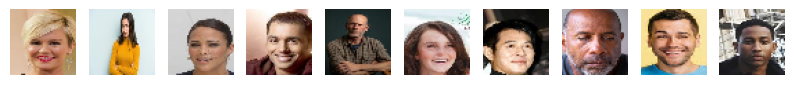

In [3]:
# Exemple d'utilisation
path_to_dataset = '../dataset_upgrade'
image_size = 48  # Vous pouvez ajuster cette taille
X_train, y_train, X_test, y_test = load_dataset(path_to_dataset, image_size)
X_train, y_train = shuffle_dataset(X_train, y_train, seed)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

display_images(X_train, 10)

input_shape = X_train[0].shape 

X_train_flat = X_train.flatten()/255.
X_test_flat = X_test.flatten()/255.

y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

In [ ]:
# Créer un modèle linéaire
n_features = X_train.shape[1] * X_train.shape[2] * X_train.shape[3]
n_classes = y_train.shape[1]
model_ptr = my_lib.create_MyLinearModel(n_features, n_classes, seed)

# Entraîner le modèle
learning_rate = 0.01
epochs = 10000
is_classification = True

my_lib.train_MyLinearModel(
    model_ptr,
    X_train.flatten().astype(np.double),
    y_train.flatten().astype(np.double),
    X_test.flatten().astype(np.double),
    y_test.flatten().astype(np.double),
    X_train.shape[0], X_test.shape[0],
    n_features, n_classes,
    learning_rate, epochs,
    int(is_classification)
)

Training starting...
Epoch 0: Train Loss: 3.0946, Test Loss: 2.8454, Train Acc: 40.1%, Test Acc: 38.4%
Epoch 1: Train Loss: 3.0336, Test Loss: 3.0389, Train Acc: 41.5%, Test Acc: 38.1%
Epoch 2: Train Loss: 3.0125, Test Loss: 3.5795, Train Acc: 41.2%, Test Acc: 37.0%
Epoch 3: Train Loss: 2.9944, Test Loss: 4.8108, Train Acc: 41.8%, Test Acc: 38.1%
Epoch 4: Train Loss: 2.9638, Test Loss: 2.9622, Train Acc: 42.8%, Test Acc: 38.0%
Epoch 5: Train Loss: 2.9684, Test Loss: 2.8757, Train Acc: 42.7%, Test Acc: 37.7%
Epoch 6: Train Loss: 2.9741, Test Loss: 2.6714, Train Acc: 42.0%, Test Acc: 37.9%
Epoch 7: Train Loss: 2.9296, Test Loss: 3.0303, Train Acc: 43.1%, Test Acc: 38.8%
Epoch 8: Train Loss: 2.9307, Test Loss: 3.4886, Train Acc: 42.9%, Test Acc: 38.1%
Epoch 9: Train Loss: 2.9510, Test Loss: 2.2930, Train Acc: 42.5%, Test Acc: 37.8%
Epoch 10: Train Loss: 2.9226, Test Loss: 3.6659, Train Acc: 43.5%, Test Acc: 38.1%
Epoch 11: Train Loss: 2.9191, Test Loss: 2.4432, Train Acc: 43.1%, Test Acc: